In [6]:
from google.colab import files
import pandas as pd

# Upload the file
uploaded = files.upload()

# Read the uploaded Excel file
df = pd.read_excel(next(iter(uploaded)))
df.head()

Saving Data for healthcare analyst.xlsx to Data for healthcare analyst.xlsx


,Member ID Encrypted,EBM Numerator,EBM Denominator,ORIG_PREFERRED_LANGUAGE,SRC_LANGUAGE,ORIG_RACE,SRC_RACE,Original Member Ethnicity,SRC_ETHNICITY,Zip (5-digit)
0,ENP71F5G7A8ZH7PJFH01A,1,1,Russian,Russian,White,Unknown,Not Hispanic or Latino,White,ZA2A2
1,7V00EYW97PM1P7E6GPAC0,1,1,English,English,Do not wish to answer,Decline to State,Not Hispanic or Latino,Asian,QRALH
2,6909Q42EJM6ADFLZC3XU1G46371EM7NHKZ,0,1,English,Unknown,Unknown,Unknown,Unknown,Unknown,98837
3,08V7XYG7P77EBPLEKPN1UV56371EM7NHKZ,0,1,English,Unknown,White,Unknown,Not Hispanic or Latino,Unknown,99110
4,0E5GG7PXGTYUX608IBQJSY98KV08KVT5L,1,1,English,Unknown,White,Unknown,Hispanic or Latino,Unknown,98837


In [10]:
# Step 0: install XGBoost (optional)
!pip install -q xgboost

In [11]:
# Step 1: imports and output folder
import os
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib

from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, classification_report, confusion_matrix, roc_curve
)

OUT_DIR = Path("/content/analysis_outputs")
OUT_DIR.mkdir(exist_ok=True)
print("Outputs will be saved to:", OUT_DIR)

Outputs will be saved to: /content/analysis_outputs


In [12]:
# Step 2: load first non-empty sheet from your Excel workbook
DATA_PATH = "/content/Data for healthcare analyst.xlsx"  # change if needed

xls = pd.ExcelFile(DATA_PATH)
df = None
for s in xls.sheet_names:
    tmp = pd.read_excel(xls, sheet_name=s)
    if tmp.shape[0] > 0:
        df = tmp.copy()
        sheet_used = s
        break
if df is None:
    raise RuntimeError("No non-empty sheet found in the Excel file.")
print(f"Loaded sheet: '{sheet_used}', shape: {df.shape}")
df.head()


Loaded sheet: 'Data for healthcare analyst 2 a', shape: (6597, 10)


,Member ID Encrypted,EBM Numerator,EBM Denominator,ORIG_PREFERRED_LANGUAGE,SRC_LANGUAGE,ORIG_RACE,SRC_RACE,Original Member Ethnicity,SRC_ETHNICITY,Zip (5-digit)
0,ENP71F5G7A8ZH7PJFH01A,1,1,Russian,Russian,White,Unknown,Not Hispanic or Latino,White,ZA2A2
1,7V00EYW97PM1P7E6GPAC0,1,1,English,English,Do not wish to answer,Decline to State,Not Hispanic or Latino,Asian,QRALH
2,6909Q42EJM6ADFLZC3XU1G46371EM7NHKZ,0,1,English,Unknown,Unknown,Unknown,Unknown,Unknown,98837
3,08V7XYG7P77EBPLEKPN1UV56371EM7NHKZ,0,1,English,Unknown,White,Unknown,Not Hispanic or Latino,Unknown,99110
4,0E5GG7PXGTYUX608IBQJSY98KV08KVT5L,1,1,English,Unknown,White,Unknown,Hispanic or Latino,Unknown,98837


In [13]:
# Step 3: quick summary: dtypes, missing, unique counts
print("Columns and dtypes:\n", df.dtypes)
print("\nShape:", df.shape)
missing = df.isnull().sum().sort_values(ascending=False)
missing_pct = (missing / len(df) * 100).round(2)
summary = pd.concat([missing, missing_pct], axis=1)
summary.columns = ["missing_count", "missing_percent"]
print("\nMissing value summary (top 20):")
print(summary.head(20))

# Save summary
summary.to_csv(OUT_DIR / "missing_summary.csv")
print("Saved missing summary.")


Columns and dtypes:
 Member ID Encrypted          object
EBM Numerator                 int64
EBM Denominator               int64
ORIG_PREFERRED_LANGUAGE      object
SRC_LANGUAGE                 object
ORIG_RACE                    object
SRC_RACE                     object
Original Member Ethnicity    object
SRC_ETHNICITY                object
Zip (5-digit)                object
dtype: object

Shape: (6597, 10)

Missing value summary (top 20):
                           missing_count  missing_percent
Member ID Encrypted                    0              0.0
EBM Numerator                          0              0.0
EBM Denominator                        0              0.0
ORIG_PREFERRED_LANGUAGE                0              0.0
SRC_LANGUAGE                           0              0.0
ORIG_RACE                              0              0.0
SRC_RACE                               0              0.0
Original Member Ethnicity              0              0.0
SRC_ETHNICITY                  

In [14]:
# Step 4: auto-detect a binary target, otherwise fallback to last column
possible_target_names = ['target','label','outcome','y','diagnosis','Result','result','Outcome','status']
target_col = None
for name in possible_target_names:
    if name in df.columns:
        target_col = name
        break

if target_col is None:
    for c in df.columns:
        if df[c].dropna().nunique() == 2:
            target_col = c
            break

if target_col is None:
    target_col = df.columns[-1]   # fallback
    print("No obvious binary target; selected last column as target:", target_col)
else:
    print("Auto-detected target column:", target_col)

print("Target value counts:\n", df[target_col].value_counts(dropna=False))


Auto-detected target column: EBM Numerator
Target value counts:
 EBM Numerator
1    4184
0    2413
Name: count, dtype: int64


In [15]:
# Step 5: convert target to binary if it's multi-class (simple rule)
y = df[target_col].copy()
X = df.drop(columns=[target_col])

if y.dropna().nunique() > 2:
    print("Target has more than 2 classes. Converting to binary.")
    if pd.api.types.is_numeric_dtype(y):
        med = y.median()
        df["_target_binary"] = (y > med).astype(int)
    else:
        top = y.mode().iloc[0]
        df["_target_binary"] = (y == top).astype(int)
    target_col = "_target_binary"
    y = df[target_col]
    X = df.drop(columns=[target_col])
    print("Created binary target:", target_col)

print("Final target distribution:\n", y.value_counts())


Final target distribution:
 EBM Numerator
1    4184
0    2413
Name: count, dtype: int64


In [16]:
# Step 6: drop columns with >80% missing (adjust threshold if needed)
missing_pct = X.isnull().mean() * 100
drop_cols = missing_pct[missing_pct > 80].index.tolist()
if drop_cols:
    print("Dropping columns with >80% missing:", drop_cols)
    X = X.drop(columns=drop_cols)
else:
    print("No columns with >80% missing.")


No columns with >80% missing.


In [17]:
# Step 7: identify numeric & categorical features
numeric_cols = X.select_dtypes(include=[np.number]).columns.tolist()
categorical_cols = X.select_dtypes(include=['object','category','bool']).columns.tolist()
print(f"Numeric columns ({len(numeric_cols)}):", numeric_cols[:20])
print(f"Categorical columns ({len(categorical_cols)}):", categorical_cols[:20])


Numeric columns (1): ['EBM Denominator']
Categorical columns (8): ['Member ID Encrypted', 'ORIG_PREFERRED_LANGUAGE', 'SRC_LANGUAGE', 'ORIG_RACE', 'SRC_RACE', 'Original Member Ethnicity', 'SRC_ETHNICITY', 'Zip (5-digit)']


In [18]:
# Step 8: frequency-encode high-cardinality categorical and one-hot low-cardinality ones
low_card_cat = [c for c in categorical_cols if X[c].nunique(dropna=True) <= 20]
high_card_cat = [c for c in categorical_cols if c not in low_card_cat]

print("Low-cardinality (one-hot):", low_card_cat)
print("High-cardinality (freq-encode):", high_card_cat)

# Frequency-encode high-card columns
for c in high_card_cat:
    freq = X[c].fillna("MISSING").value_counts(normalize=True)
    X[c + "_freq"] = X[c].fillna("MISSING").map(freq).astype(float)
X = X.drop(columns=high_card_cat)

# update the lists
freq_cols = [c for c in X.columns if c.endswith("_freq")]
low_card_cat = [c for c in low_card_cat if c in X.columns]
print("After encoding, freq columns:", freq_cols[:10])


Low-cardinality (one-hot): ['ORIG_RACE', 'Original Member Ethnicity']
High-cardinality (freq-encode): ['Member ID Encrypted', 'ORIG_PREFERRED_LANGUAGE', 'SRC_LANGUAGE', 'SRC_RACE', 'SRC_ETHNICITY', 'Zip (5-digit)']
After encoding, freq columns: ['Member ID Encrypted_freq', 'ORIG_PREFERRED_LANGUAGE_freq', 'SRC_LANGUAGE_freq', 'SRC_RACE_freq', 'SRC_ETHNICITY_freq', 'Zip (5-digit)_freq']


In [20]:
# Step 9: preprocessing pipeline (impute numeric, scale; impute categorical, one-hot)
numeric_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])
categorical_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore")) # Removed sparse=True
])

preprocessor = ColumnTransformer([
    ("num", numeric_transformer, numeric_cols),
    ("cat", categorical_transformer, low_card_cat)
], remainder="passthrough")  # keep freq-encoded columns as-is
print("Preprocessor constructed.")

Preprocessor constructed.


In [22]:
# === Evaluation helper ===
def evaluate_pipeline(name, estimator, X_tr, X_te, y_tr, y_te, cv_folds=3):
    pipe = Pipeline([("pre", preprocessor), ("clf", estimator)])
    cv = StratifiedKFold(n_splits=cv_folds, shuffle=True, random_state=42)
    print(f"\n{name}: running {cv_folds}-fold CV (ROC AUC)...")
    try:
        cv_scores = cross_val_score(pipe, X_tr, y_tr, cv=cv, scoring="roc_auc", n_jobs=1)
        print(f"CV ROC AUC: {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")
    except Exception as e:
        print("Cross-val failed:", e)
    # Fit on full train
    pipe.fit(X_tr, y_tr)
    y_pred = pipe.predict(X_te)
    y_proba = pipe.predict_proba(X_te)[:,1] if hasattr(pipe.named_steps['clf'], "predict_proba") else None

    print("Accuracy:", accuracy_score(y_te, y_pred))
    print("Precision:", precision_score(y_te, y_pred, zero_division=0))
    print("Recall:", recall_score(y_te, y_pred, zero_division=0))
    print("F1:", f1_score(y_te, y_pred, zero_division=0))
    if y_proba is not None:
        try:
            auc = roc_auc_score(y_te, y_proba)
            print("ROC AUC:", auc)
            fpr, tpr, _ = roc_curve(y_te, y_proba)
            plt.figure(figsize=(5,4))
            plt.plot(fpr, tpr)
            plt.plot([0,1],[0,1],'--')
            plt.title(f"ROC - {name}")
            plt.xlabel("FPR"); plt.ylabel("TPR")
            plt.tight_layout()
            plt.savefig(OUT_DIR / f"roc_{name.replace(' ','_')}.png")
            plt.close()
        except Exception as e:
            print("ROC AUC calculation failed:", e)

    print("\nClassification report:\n", classification_report(y_te, y_pred, zero_division=0))
    cm = confusion_matrix(y_te, y_pred)
    print("Confusion matrix:\n", cm)

    # Save the pipeline for later use
    save_path = OUT_DIR / f"{name.replace(' ','_').lower()}_pipeline.joblib"
    joblib.dump(pipe, save_path)
    print("Saved pipeline to:", save_path)
    return pipe

# === Fit models ===
print("\nTraining Logistic Regression...")
lr_pipe = evaluate_pipeline("LogisticRegression", LogisticRegression(max_iter=1000, solver="liblinear"), X_train, X_test, y_train, y_test)

print("\nTraining Random Forest...")
rf_pipe = evaluate_pipeline("RandomForest", RandomForestClassifier(n_estimators=100, random_state=42), X_train, X_test, y_train, y_test)

# XGBoost: optional. If xgboost is installed, it will run. Otherwise it will skip.
try:
    from xgboost import XGBClassifier
    print("\nTraining XGBoost (if installed)...")
    xgb_pipe = evaluate_pipeline("XGBoost", XGBClassifier(use_label_encoder=False, eval_metric="logloss", random_state=42), X_train, X_test, y_train, y_test)
except Exception as e:
    print("XGBoost not installed or failed to import. Skipping XGBoost. (Install xgboost to enable.)")


Training Logistic Regression...

LogisticRegression: running 3-fold CV (ROC AUC)...
CV ROC AUC: 0.5992 ± 0.0030
Accuracy: 0.6378787878787879
Precision: 0.6428003182179793
Recall: 0.965352449223417
F1: 0.7717287488061128
ROC AUC: 0.5957798110673286

Classification report:
               precision    recall  f1-score   support

           0       0.54      0.07      0.12       483
           1       0.64      0.97      0.77       837

    accuracy                           0.64      1320
   macro avg       0.59      0.52      0.45      1320
weighted avg       0.61      0.64      0.53      1320

Confusion matrix:
 [[ 34 449]
 [ 29 808]]
Saved pipeline to: /content/analysis_outputs/logisticregression_pipeline.joblib

Training Random Forest...

RandomForest: running 3-fold CV (ROC AUC)...
CV ROC AUC: 0.5780 ± 0.0081
Accuracy: 0.6151515151515151
Precision: 0.6701137538779731
Recall: 0.7741935483870968
F1: 0.7184035476718403
ROC AUC: 0.5910342319879487

Classification report:
               

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:183: UserWarning: [07:28:02] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:183: UserWarning: [07:28:02] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:183: UserWarning: [07:28:02] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:183: UserWarning: [07:28:02] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


CV ROC AUC: 0.5928 ± 0.0086
Accuracy: 0.6287878787878788
Precision: 0.662605435801312
Recall: 0.8446833930704899
F1: 0.7426470588235294
ROC AUC: 0.6085225009956192

Classification report:
               precision    recall  f1-score   support

           0       0.49      0.25      0.33       483
           1       0.66      0.84      0.74       837

    accuracy                           0.63      1320
   macro avg       0.57      0.55      0.54      1320
weighted avg       0.60      0.63      0.59      1320

Confusion matrix:
 [[123 360]
 [130 707]]
Saved pipeline to: /content/analysis_outputs/xgboost_pipeline.joblib


In [21]:
# Step 10: Train/test split
X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y, test_size=0.2, random_state=42)
print("Train/test shapes:", X_train.shape, X_test.shape)

Train/test shapes: (5277, 9) (1320, 9)


In [23]:
# Step 10: train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, stratify=y, test_size=0.2, random_state=42
)
print("Train shape:", X_train.shape, "Test shape:", X_test.shape)
print("Train target distribution:\n", y_train.value_counts(normalize=True))

Train shape: (5277, 9) Test shape: (1320, 9)
Train target distribution:
 EBM Numerator
1    0.634262
0    0.365738
Name: proportion, dtype: float64


In [24]:
# Step 11: Logistic Regression
log_pipe = Pipeline([("pre", preprocessor), ("clf", LogisticRegression(max_iter=1000, solver="liblinear"))])

cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
print("Running 3-fold CV (ROC AUC)...")
cv_scores = cross_val_score(log_pipe, X_train, y_train, cv=cv, scoring="roc_auc", n_jobs=1)
print("CV ROC AUC:", cv_scores.mean(), "±", cv_scores.std())

log_pipe.fit(X_train, y_train)
y_pred = log_pipe.predict(X_test)
y_proba = log_pipe.predict_proba(X_test)[:,1]

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred, zero_division=0))
print("Recall:", recall_score(y_test, y_pred, zero_division=0))
print("F1:", f1_score(y_test, y_pred, zero_division=0))
print("ROC AUC:", roc_auc_score(y_test, y_proba))
print("\nClassification report:\n", classification_report(y_test, y_pred, zero_division=0))
print("Confusion matrix:\n", confusion_matrix(y_test, y_pred))

# save model
joblib.dump(log_pipe, OUT_DIR / "logistic_pipeline.joblib")
print("Saved logistic pipeline.")

Running 3-fold CV (ROC AUC)...
CV ROC AUC: 0.5991824578864743 ± 0.0029537720346469623
Accuracy: 0.6378787878787879
Precision: 0.6428003182179793
Recall: 0.965352449223417
F1: 0.7717287488061128
ROC AUC: 0.5957798110673286

Classification report:
               precision    recall  f1-score   support

           0       0.54      0.07      0.12       483
           1       0.64      0.97      0.77       837

    accuracy                           0.64      1320
   macro avg       0.59      0.52      0.45      1320
weighted avg       0.61      0.64      0.53      1320

Confusion matrix:
 [[ 34 449]
 [ 29 808]]
Saved logistic pipeline.


In [25]:
# Step 11: Logistic Regression
log_pipe = Pipeline([("pre", preprocessor), ("clf", LogisticRegression(max_iter=1000, solver="liblinear"))])

cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
print("Running 3-fold CV (ROC AUC)...")
cv_scores = cross_val_score(log_pipe, X_train, y_train, cv=cv, scoring="roc_auc", n_jobs=1)
print("CV ROC AUC:", cv_scores.mean(), "±", cv_scores.std())

log_pipe.fit(X_train, y_train)
y_pred = log_pipe.predict(X_test)
y_proba = log_pipe.predict_proba(X_test)[:,1]

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred, zero_division=0))
print("Recall:", recall_score(y_test, y_pred, zero_division=0))
print("F1:", f1_score(y_test, y_pred, zero_division=0))
print("ROC AUC:", roc_auc_score(y_test, y_proba))
print("\nClassification report:\n", classification_report(y_test, y_pred, zero_division=0))
print("Confusion matrix:\n", confusion_matrix(y_test, y_pred))

# save model
joblib.dump(log_pipe, OUT_DIR / "logistic_pipeline.joblib")
print("Saved logistic pipeline.")

Running 3-fold CV (ROC AUC)...
CV ROC AUC: 0.5991824578864743 ± 0.0029537720346469623
Accuracy: 0.6378787878787879
Precision: 0.6428003182179793
Recall: 0.965352449223417
F1: 0.7717287488061128
ROC AUC: 0.5957798110673286

Classification report:
               precision    recall  f1-score   support

           0       0.54      0.07      0.12       483
           1       0.64      0.97      0.77       837

    accuracy                           0.64      1320
   macro avg       0.59      0.52      0.45      1320
weighted avg       0.61      0.64      0.53      1320

Confusion matrix:
 [[ 34 449]
 [ 29 808]]
Saved logistic pipeline.


In [26]:
# Step 11: Logistic Regression
log_pipe = Pipeline([("pre", preprocessor), ("clf", LogisticRegression(max_iter=1000, solver="liblinear"))])

cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
print("Running 3-fold CV (ROC AUC)...")
cv_scores = cross_val_score(log_pipe, X_train, y_train, cv=cv, scoring="roc_auc", n_jobs=1)
print("CV ROC AUC:", cv_scores.mean(), "±", cv_scores.std())

log_pipe.fit(X_train, y_train)
y_pred = log_pipe.predict(X_test)
y_proba = log_pipe.predict_proba(X_test)[:,1]

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred, zero_division=0))
print("Recall:", recall_score(y_test, y_pred, zero_division=0))
print("F1:", f1_score(y_test, y_pred, zero_division=0))
print("ROC AUC:", roc_auc_score(y_test, y_proba))
print("\nClassification report:\n", classification_report(y_test, y_pred, zero_division=0))
print("Confusion matrix:\n", confusion_matrix(y_test, y_pred))

# save model
joblib.dump(log_pipe, OUT_DIR / "logistic_pipeline.joblib")
print("Saved logistic pipeline.")


Running 3-fold CV (ROC AUC)...
CV ROC AUC: 0.5991824578864743 ± 0.0029537720346469623
Accuracy: 0.6378787878787879
Precision: 0.6428003182179793
Recall: 0.965352449223417
F1: 0.7717287488061128
ROC AUC: 0.5957798110673286

Classification report:
               precision    recall  f1-score   support

           0       0.54      0.07      0.12       483
           1       0.64      0.97      0.77       837

    accuracy                           0.64      1320
   macro avg       0.59      0.52      0.45      1320
weighted avg       0.61      0.64      0.53      1320

Confusion matrix:
 [[ 34 449]
 [ 29 808]]
Saved logistic pipeline.


In [27]:
# Step 12: Random Forest
rf_pipe = Pipeline([("pre", preprocessor), ("clf", RandomForestClassifier(n_estimators=100, random_state=42))])

cv_scores = cross_val_score(rf_pipe, X_train, y_train, cv=StratifiedKFold(n_splits=3, shuffle=True, random_state=42), scoring="roc_auc", n_jobs=1)
print("RF CV ROC AUC:", cv_scores.mean(), "±", cv_scores.std())

rf_pipe.fit(X_train, y_train)
y_pred = rf_pipe.predict(X_test)
y_proba = rf_pipe.predict_proba(X_test)[:,1]

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred, zero_division=0))
print("Recall:", recall_score(y_test, y_pred, zero_division=0))
print("F1:", f1_score(y_test, y_pred, zero_division=0))
print("ROC AUC:", roc_auc_score(y_test, y_proba))
print("\nClassification report:\n", classification_report(y_test, y_pred, zero_division=0))
print("Confusion matrix:\n", confusion_matrix(y_test, y_pred))

# save model
joblib.dump(rf_pipe, OUT_DIR / "randomforest_pipeline.joblib")
print("Saved random forest pipeline.")


RF CV ROC AUC: 0.5780420325410043 ± 0.008114569662716025
Accuracy: 0.6151515151515151
Precision: 0.6701137538779731
Recall: 0.7741935483870968
F1: 0.7184035476718403
ROC AUC: 0.5910342319879487

Classification report:
               precision    recall  f1-score   support

           0       0.46      0.34      0.39       483
           1       0.67      0.77      0.72       837

    accuracy                           0.62      1320
   macro avg       0.57      0.56      0.56      1320
weighted avg       0.59      0.62      0.60      1320

Confusion matrix:
 [[164 319]
 [189 648]]
Saved random forest pipeline.


In [28]:
# Step 13: XGBoost (optional). Run only if you installed xgboost (see Step 0)
try:
    from xgboost import XGBClassifier
    xgb_pipe = Pipeline([("pre", preprocessor), ("clf", XGBClassifier(use_label_encoder=False, eval_metric="logloss", random_state=42))])
    cv_scores = cross_val_score(xgb_pipe, X_train, y_train, cv=StratifiedKFold(n_splits=3, shuffle=True, random_state=42), scoring="roc_auc", n_jobs=1)
    print("XGB CV ROC AUC:", cv_scores.mean(), "±", cv_scores.std())
    xgb_pipe.fit(X_train, y_train)
    y_pred = xgb_pipe.predict(X_test)
    y_proba = xgb_pipe.predict_proba(X_test)[:,1]
    print("Accuracy:", accuracy_score(y_test, y_pred))
    print("ROC AUC:", roc_auc_score(y_test, y_proba))
    print("\nClassification report:\n", classification_report(y_test, y_pred, zero_division=0))
    joblib.dump(xgb_pipe, OUT_DIR / "xgboost_pipeline.joblib")
    print("Saved xgboost pipeline.")
except Exception as e:
    print("XGBoost not available or failed to run:", e)


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:183: UserWarning: [07:56:06] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:183: UserWarning: [07:56:06] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:183: UserWarning: [07:56:06] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:183: UserWarning: [07:56:06] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


XGB CV ROC AUC: 0.5927709953941833 ± 0.008612251725448236
Accuracy: 0.6287878787878788
ROC AUC: 0.6085225009956192

Classification report:
               precision    recall  f1-score   support

           0       0.49      0.25      0.33       483
           1       0.66      0.84      0.74       837

    accuracy                           0.63      1320
   macro avg       0.57      0.55      0.54      1320
weighted avg       0.60      0.63      0.59      1320

Saved xgboost pipeline.


In [29]:
# Step 14: Feature importances (RF) and Logistic coefficients (approx)
# We need to extract feature names after preprocessing.
preprocessor.fit(X_train)

# numeric names
num_names = numeric_cols

# one-hot feature names (if any)
if low_card_cat:
    ohe = preprocessor.named_transformers_['cat'].named_steps['onehot']
    ohe_names = list(ohe.get_feature_names_out(low_card_cat))
else:
    ohe_names = []

# columns passed through (freq columns) - remainder
passthrough_cols = [c for c in X.columns if c not in num_names + low_card_cat]
feature_names = num_names + ohe_names + passthrough_cols

# Random Forest importances
rf_clf = rf_pipe.named_steps['clf']
importances = rf_clf.feature_importances_
fi = pd.DataFrame({"feature": feature_names, "importance": importances})
fi = fi.sort_values("importance", ascending=False).head(30)
print("Top Random Forest importances:\n", fi)
fi.to_csv(OUT_DIR / "rf_top_feature_importances.csv", index=False)
print("Saved RF feature importances.")

# Logistic coefficients (if sizes match)
try:
    log_clf = log_pipe.named_steps['clf']
    coef = log_clf.coef_.ravel()
    if len(coef) == len(feature_names):
        coef_df = pd.DataFrame({"feature": feature_names, "coef": coef})
        coef_df = coef_df.sort_values("coef", key=abs, ascending=False).head(30)
        print("Top logistic coefficients:\n", coef_df)
        coef_df.to_csv(OUT_DIR / "logistic_top_coefficients.csv", index=False)
        print("Saved logistic coefficients.")
    else:
        print("Coefficient count does not match feature count; skipping logistic coef export.")
except Exception as e:
    print("Could not extract logistic coefficients:", e)

Top Random Forest importances:
                                              feature  importance
19                                Zip (5-digit)_freq    0.566764
17                                     SRC_RACE_freq    0.130320
16                                 SRC_LANGUAGE_freq    0.084012
15                      ORIG_PREFERRED_LANGUAGE_freq    0.072989
18                                SRC_ETHNICITY_freq    0.071579
10                                   ORIG_RACE_White    0.013563
12  Original Member Ethnicity_Not Hispanic or Latino    0.009771
11      Original Member Ethnicity_Hispanic or Latino    0.009196
4                    ORIG_RACE_Do not wish to answer    0.008830
2                                    ORIG_RACE_Asian    0.008656
13                 Original Member Ethnicity_Unknown    0.004465
9                                  ORIG_RACE_Unknown    0.004459
3                ORIG_RACE_Black or African American    0.004134
8                        ORIG_RACE_Two or more races    0.

In [30]:
# Step 15: Save data summary
col_summary = pd.DataFrame({
    "column": df.columns,
    "dtype": [str(df[c].dtype) for c in df.columns],
    "n_missing": [int(df[c].isnull().sum()) for c in df.columns],
    "n_unique": [int(df[c].nunique(dropna=True)) for c in df.columns]
})
col_summary.to_csv(OUT_DIR / "data_summary.csv", index=False)
print("Saved data_summary.csv to", OUT_DIR)


Saved data_summary.csv to /content/analysis_outputs


In [31]:
# Step 16: list created files and show download links (Colab)
for p in sorted(Path("/content/analysis_outputs").iterdir()):
    print("-", p.name)


- data_summary.csv
- logistic_pipeline.joblib
- logistic_top_coefficients.csv
- logisticregression_pipeline.joblib
- missing_summary.csv
- randomforest_pipeline.joblib
- rf_top_feature_importances.csv
- roc_LogisticRegression.png
- roc_RandomForest.png
- roc_XGBoost.png
- xgboost_pipeline.joblib


In [32]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px


In [33]:
# Basic info
print(df.info())
print(df.describe())

# Check for missing values
print(df.isnull().sum())

# Fill or drop missing values (example)
df = df.dropna()  # or df.fillna(df.mean(), inplace=True)


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6597 entries, 0 to 6596
Data columns (total 10 columns):
 #   Column                     Non-Null Count  Dtype 
---  ------                     --------------  ----- 
 0   Member ID Encrypted        6597 non-null   object
 1   EBM Numerator              6597 non-null   int64 
 2   EBM Denominator            6597 non-null   int64 
 3   ORIG_PREFERRED_LANGUAGE    6597 non-null   object
 4   SRC_LANGUAGE               6597 non-null   object
 5   ORIG_RACE                  6597 non-null   object
 6   SRC_RACE                   6597 non-null   object
 7   Original Member Ethnicity  6597 non-null   object
 8   SRC_ETHNICITY              6597 non-null   object
 9   Zip (5-digit)              6597 non-null   object
dtypes: int64(2), object(8)
memory usage: 515.5+ KB
None
       EBM Numerator  EBM Denominator
count    6597.000000           6597.0
mean        0.634228              1.0
std         0.481683              0.0
min         0.000000    

In [35]:
plt.figure(figsize=(10,6))
sns.heatmap(X.corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

ValueError: could not convert string to float: 'White'

<Figure size 1000x600 with 0 Axes>

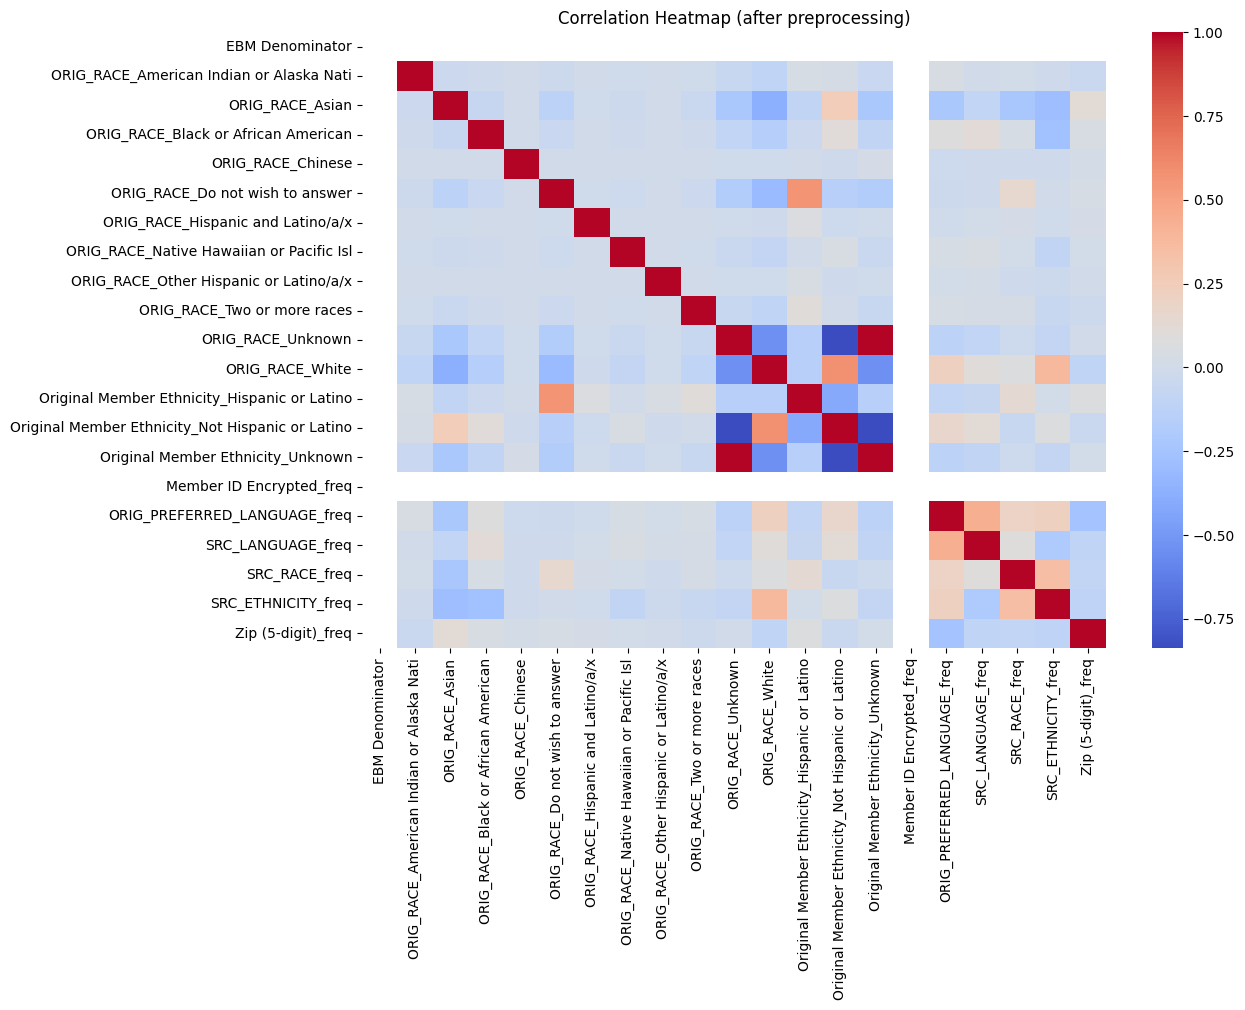

In [36]:
# Temporarily apply preprocessing for correlation heatmap visualization
# Note: This is for visualization only and is not part of the modeling pipeline flow
X_processed_for_viz = preprocessor.fit_transform(X)

# Convert the processed data (which is a sparse matrix after one-hot encoding)
# back to a dense array or DataFrame for correlation calculation and heatmap
# If your data has many one-hot encoded features, converting to dense might consume a lot of memory.
# For visualization, let's try converting to a DataFrame with appropriate column names if possible.

# Get feature names after preprocessing
# numeric names
num_names_viz = numeric_cols
# onehot names
if low_card_cat:
    ohe_viz = preprocessor.named_transformers_['cat'].named_steps['onehot']
    ohe_names_viz = list(ohe_viz.get_feature_names_out(low_card_cat))
else:
    ohe_names_viz = []
# columns passed through (freq columns) - remainder
passthrough_names_viz = [c for c in X.columns if c not in numeric_cols + low_card_cat]
feature_names_viz = num_names_viz + ohe_names_viz + passthrough_names_viz


if isinstance(X_processed_for_viz, np.ndarray):
    X_processed_df = pd.DataFrame(X_processed_for_viz, columns=feature_names_viz, index=X.index)
else: # Assuming it's a sparse matrix
    X_processed_df = pd.DataFrame(X_processed_for_viz.todense(), columns=feature_names_viz, index=X.index)


# Now generate the heatmap
plt.figure(figsize=(12, 8)) # Increased figure size for better readability
sns.heatmap(X_processed_df.corr(), annot=False, cmap='coolwarm') # annot=False for readability with many features
plt.title('Correlation Heatmap (after preprocessing)')
plt.show()

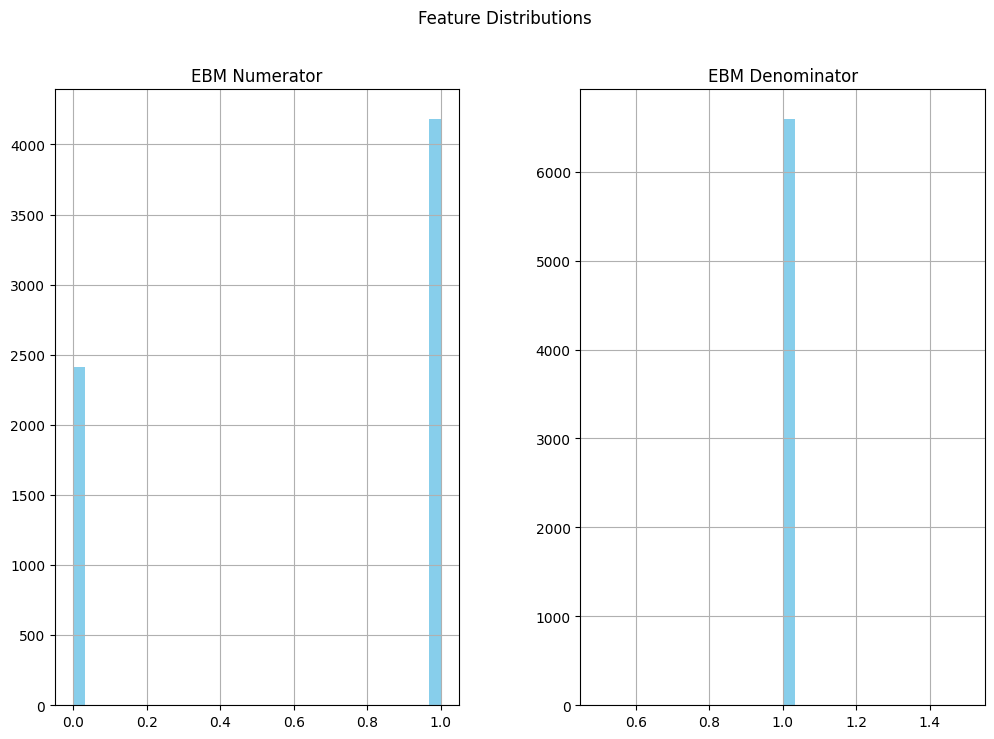

In [37]:
df.hist(bins=30, figsize=(12, 8), color='skyblue')
plt.suptitle('Feature Distributions')
plt.show()

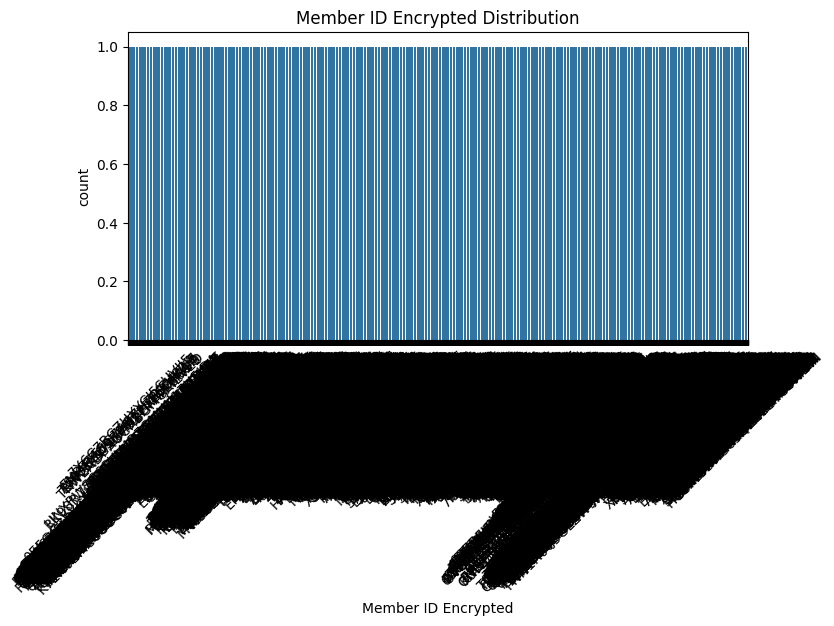

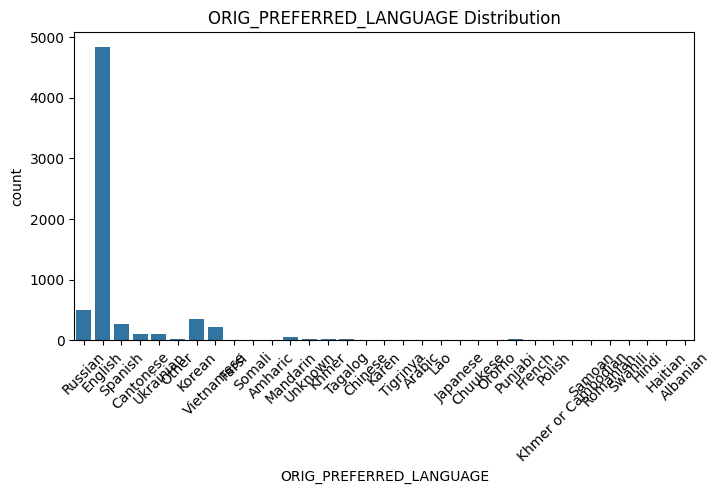

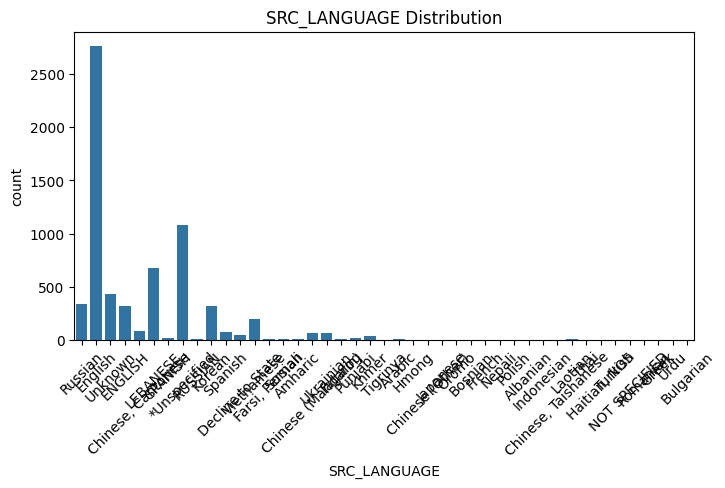

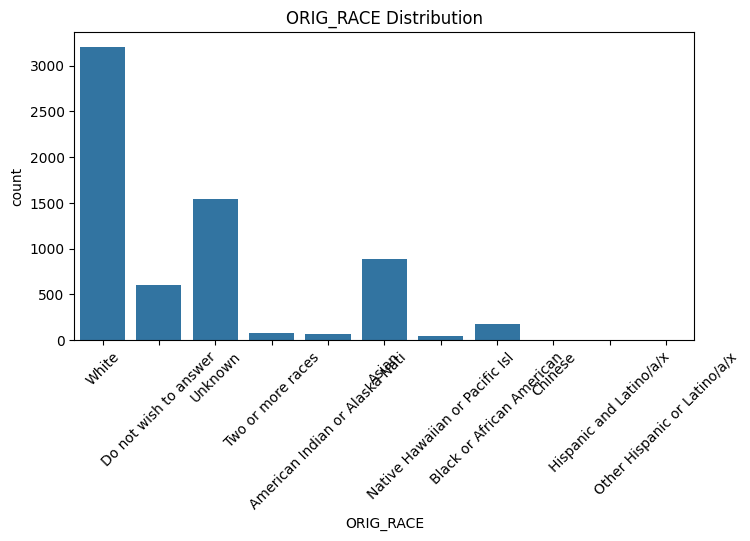

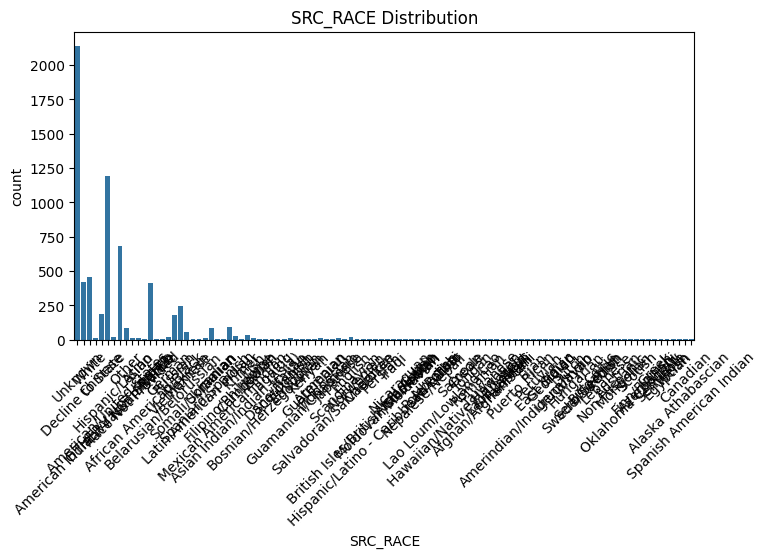

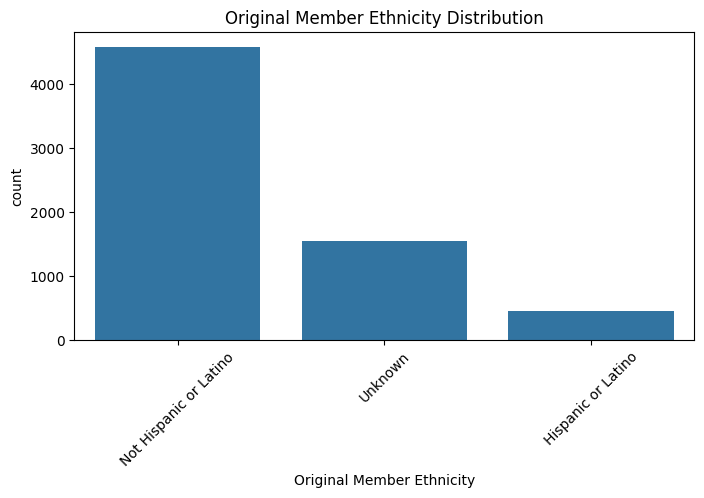

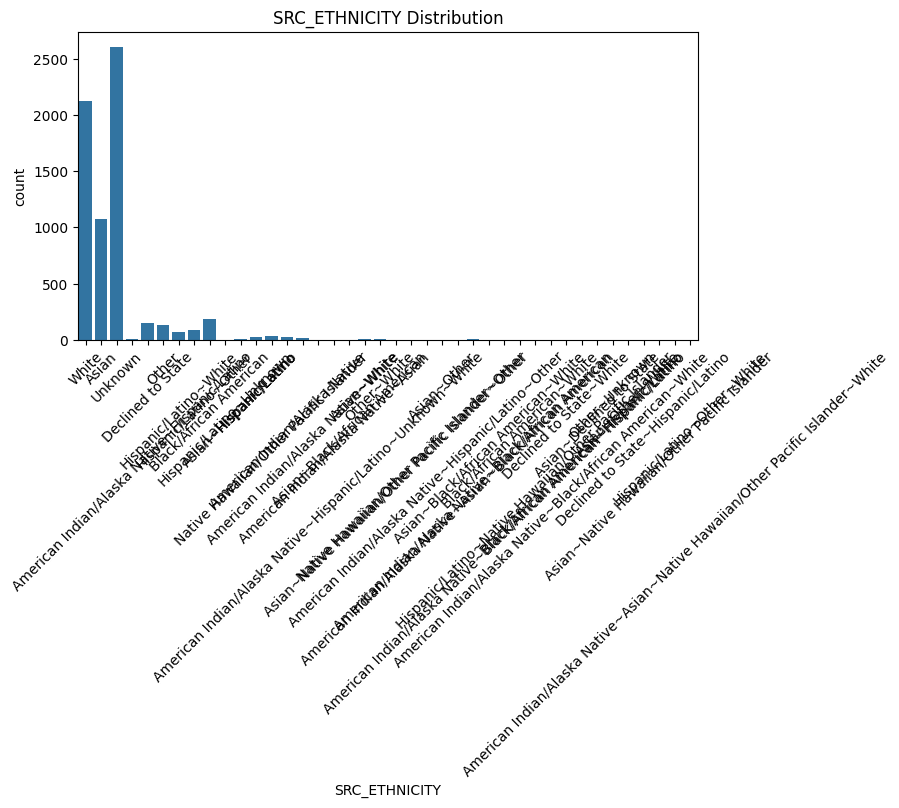

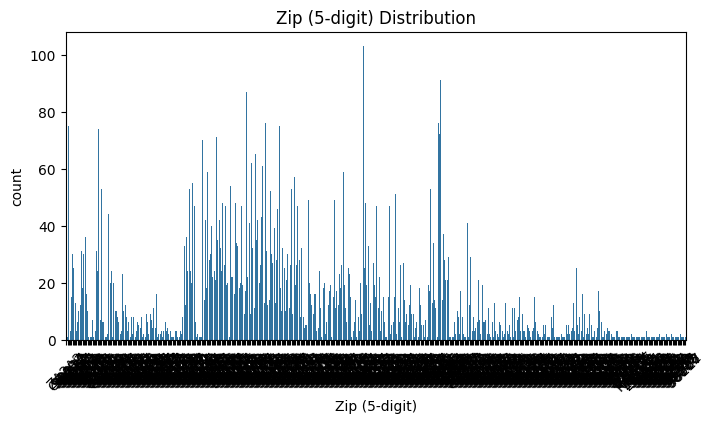

In [41]:
categorical_cols = df.select_dtypes(include='object').columns
for col in categorical_cols:
    plt.figure(figsize=(8,4))
    sns.countplot(x=df[col])
    plt.title(f'{col} Distribution')
    plt.xticks(rotation=45)
    plt.show()

In [44]:
fig = px.scatter(df, x='Original Member Ethnicity', y='ORIG_PREFERRED_LANGUAGE', color='EBM Denominator')
fig.show()

In [47]:
# Step 14: create a short EDA report as markdown
report = f"""
# EDA Summary - Healthcare dataset

Total rows: {len(df)}
Columns: {list(df.columns)}

## Target
Binary target created: `EBM_met` (1 if EBM Numerator >= EBM Denominator)

## Missing values
Top missing columns (percent):
{missing.sort_values(ascending=False).head(10).to_markdown()}

## Notes
- Categorical columns: {categorical_cols}
- Numeric columns: {numeric_cols}
- Models trained: Logistic Regression, Random Forest{', XGBoost' if 'xgb_pipe' in globals() else ''}

Saved outputs: {', '.join([p.name for p in OUT_DIR.iterdir()])}
"""
with open(OUT_DIR / "EDA_readme_snippet.md", "w") as f:
    f.write(report)
print("Saved EDA README snippet:", OUT_DIR / "EDA_readme_snippet.md")

Saved EDA README snippet: /content/analysis_outputs/EDA_readme_snippet.md
